## Examen Practico - Tercer Parcial

#### 0) Cargar una de las imágenes histológicas

In [2]:
# Utilizar la librería skimage.io para leer la imagen 'histo_x.jpg' en formato RGB.
# Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
# Visualizar la imagen
#llamamos la imagen con io

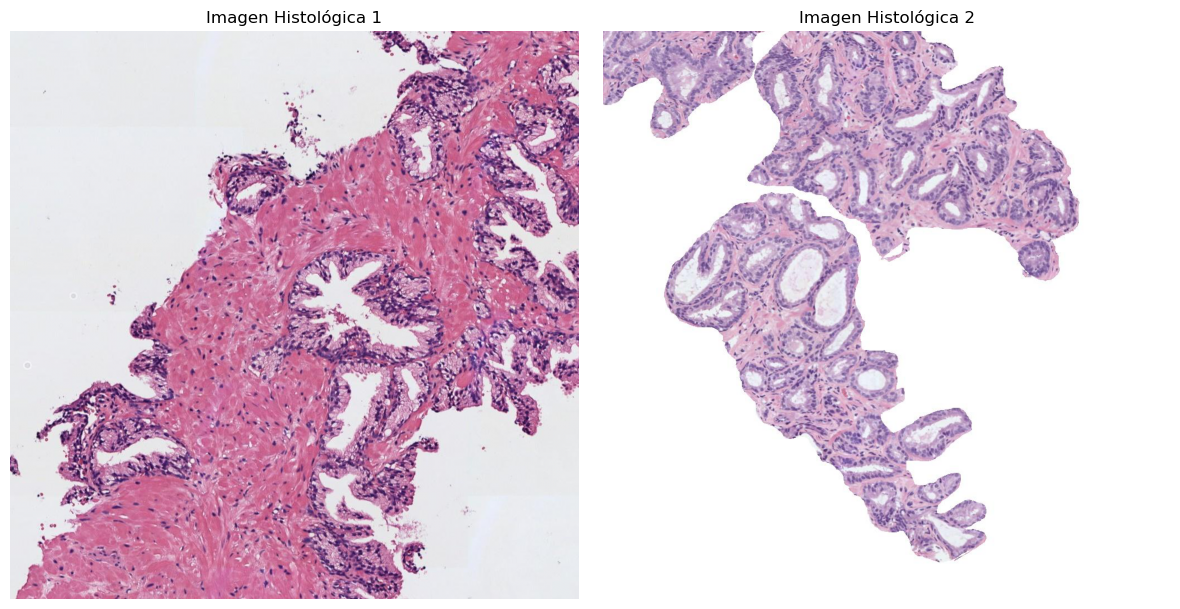

In [3]:
import matplotlib.pyplot as plt
from skimage import io

# Utilizamos la librería skimage.io para leer la imagen en formato RGB.
imagen1 = io.imread("histo_1.jpg")
imagen2 = io.imread("histo_2.jpg")
# Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
img1 = imagen1 / 255.0
img2 = imagen2 / 255.0
# Visualizar las imágenes juntas (creamos una fila con 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Mostrar la primera imagen en la primera columna
axes[0].imshow(img1)
axes[0].set_title("Imagen Histológica 1")
axes[0].axis("off")

# Mostrar la segunda imagen en la segunda columna
axes[1].imshow(img2)
axes[1].set_title("Imagen Histológica 2")
axes[1].axis("off")

# Ajustar el espacio entre imágenes y mostrarlas
plt.tight_layout()
plt.show()

#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

In [4]:
# Extraer la componente magenta de la imagen (que corresponde a la región tisular)
# Visualizar la imagen del canal magenta

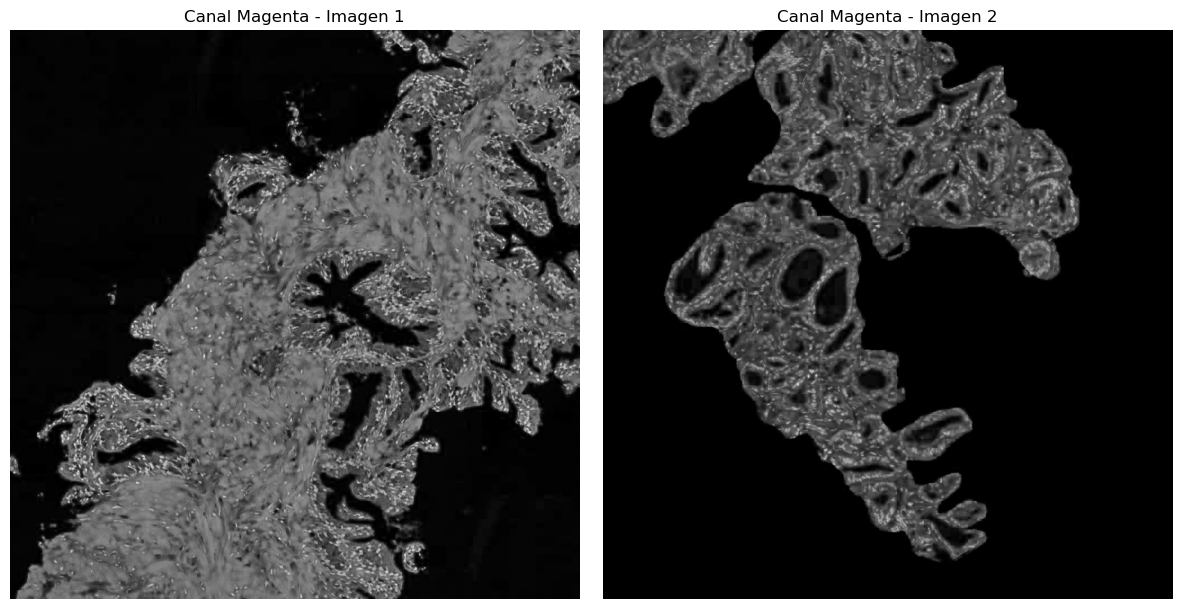

In [5]:
import cv2 # libreria que nos permite separar los canales de color
import matplotlib.pyplot as plt
import numpy as np # libreria que nos permite realizar funciones matematicas

# Usamos el bloque de control de errores para ignorar divisiones por cero
with np.errstate(invalid="ignore", divide="ignore"):

    # Procesamos la imagen 1 
    K1 = 1 - np.max(img1, axis=2) # Busca cuál es el valor más alto entre los canales de cada pixel
    C1 = (1 - img1[:, :, 0] - K1) / (1 - K1)
    M1 = (1 - img1[:, :, 1] - K1) / (1 - K1)
    Y1 = (1 - img1[:, :, 2] - K1) / (1 - K1)

    # Procesamos la imagen 2
    K2 = 1 - np.max(img2, axis=2)
    C2 = (1 - img2[:, :, 0] - K2) / (1 - K2)
    M2 = (1 - img2[:, :, 1] - K2) / (1 - K2)
    Y2 = (1 - img2[:, :, 2] - K2) / (1 - K2)

# Transformamos los los numeros estandarizados a enteros
CMYK1 = (np.dstack((C1, M1, Y1, K1)) * 255).astype("uint8") 
CMYK2 = (np.dstack((C2, M2, Y2, K2)) * 255).astype("uint8")

# Separar los canales con cv2.split 
_, M1_final, _, _ = cv2.split(CMYK1)
_, M2_final, _, _ = cv2.split(CMYK2)

# Vizualisamos la iamgen del canal magenta
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# Mostrar canal Magenta de la Imagen Histológica 1
axes[0].imshow(M1_final.astype("uint8"), cmap="gray")
axes[0].set_title("Canal Magenta - Imagen 1")
axes[0].axis("off")
# Mostrar canal Magenta de la Imagen Histológica 2
axes[1].imshow(M2_final.astype("uint8"), cmap="gray")
axes[1].set_title("Canal Magenta - Imagen 2")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

In [6]:
# Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1s y el resto de los píxeles tengan un valor de 0.
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".
# Visualizar la máscara resultante

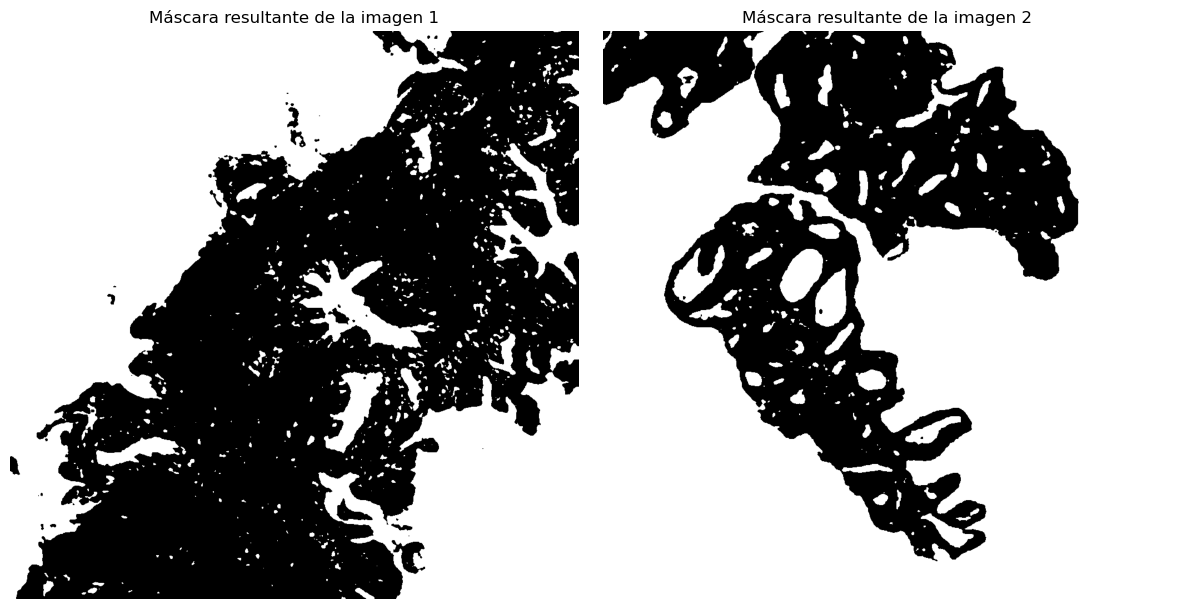

In [7]:
# Procesamos la imagen 1 
# Aplicamos un filtro gaussiano de tamaño 5x5 
blur1 = cv2.GaussianBlur(M1_final, (5, 5), 0)

# Aplicar Otsu Invertido: el fondo/lumen (oscuros) se vuelven 1, y el tejido (claro) se vuelve 0
_, mascara1 = cv2.threshold(
    blur1, 0, 1, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Procesamos la imagen 2 
blur2 = cv2.GaussianBlur(M2_final, (5, 5), 0)

# Aplicar Otsu Invertido
_, mascara2 = cv2.threshold(
    blur2, 0, 1, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)
# Visualizar la máscara resultante en paralelo
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Mostrar máscara de la Imagen 1
axes[0].imshow(mascara1, cmap="gray")
axes[0].set_title("Máscara resultante de la imagen 1")
axes[0].axis("off")

# Mostrar máscara de la Imagen 2
axes[1].imshow(mascara2, cmap="gray")
axes[1].set_title("Máscara resultante de la imagen 2")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

In [ ]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos cuya área sea menor a 300 píxeles
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects
# Visualizaer la máscara resultante

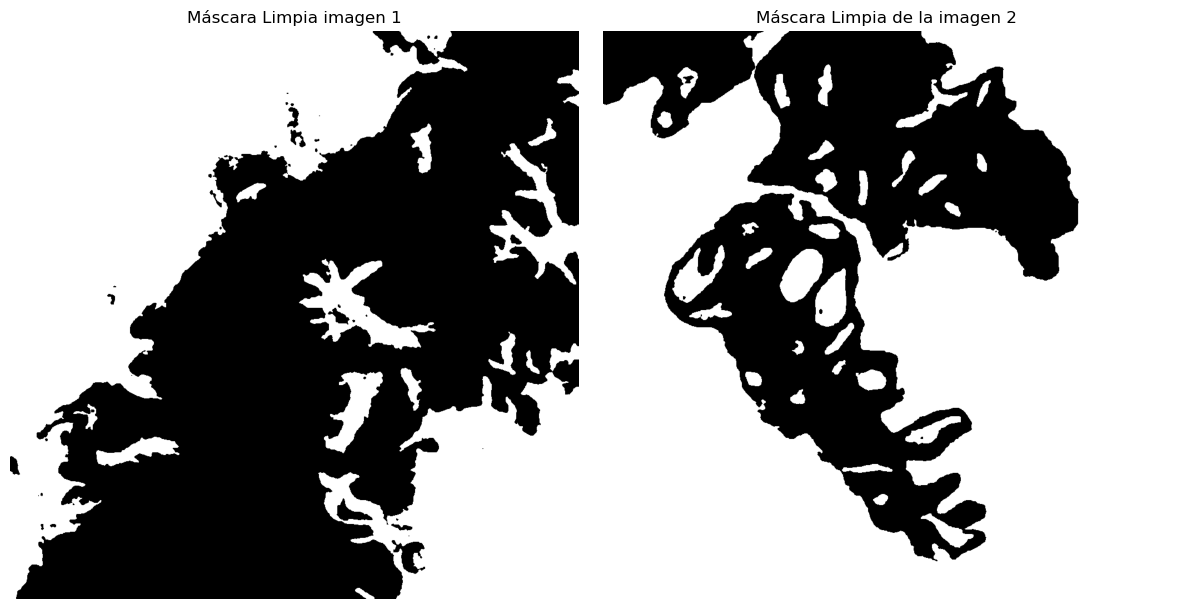

In [8]:
#Cargamos la libreria skinage.morphology
from skimage.morphology import remove_small_objects
# Limpiamos la imagen eliminando los artefactos de lumen
# Filtrar objetos blancos con un área menor a 300 píxeles en la Imagen 1
mascara1_limpia = remove_small_objects(mascara1.astype(bool), min_size=300)

# Filtrar objetos blancos con un área menor a 300 píxeles en la Imagen 2
mascara2_limpia = remove_small_objects(mascara2.astype(bool), min_size=300)

# Visualizar la máscara resultante 
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Mostrar máscara de la Imagen 1
axes[0].imshow(mascara1_limpia, cmap="gray")
axes[0].set_title("Máscara Limpia imagen 1")
axes[0].axis("off")

# Mostrar máscara de la Imagen 2
axes[1].imshow(mascara2_limpia, cmap="gray")
axes[1].set_title("Máscara Limpia de la imagen 2")
axes[1].axis("off")
plt.tight_layout()
plt.show()

#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

In [ ]:
# Aplicar el algoritmo de expansión a partir de semillas (region growing) de manera que únicamente los lúmenes sean blancos
# y el resto de la imagen negra. Pista: utilizar dos semillas. Nota: Se pueden fijar las semillas de manera manual, pero
# se valorará positivamente a aquell@s que desarrollen una función para encontrarlas automáticamente.
# Visualizar la máscara resultante. 

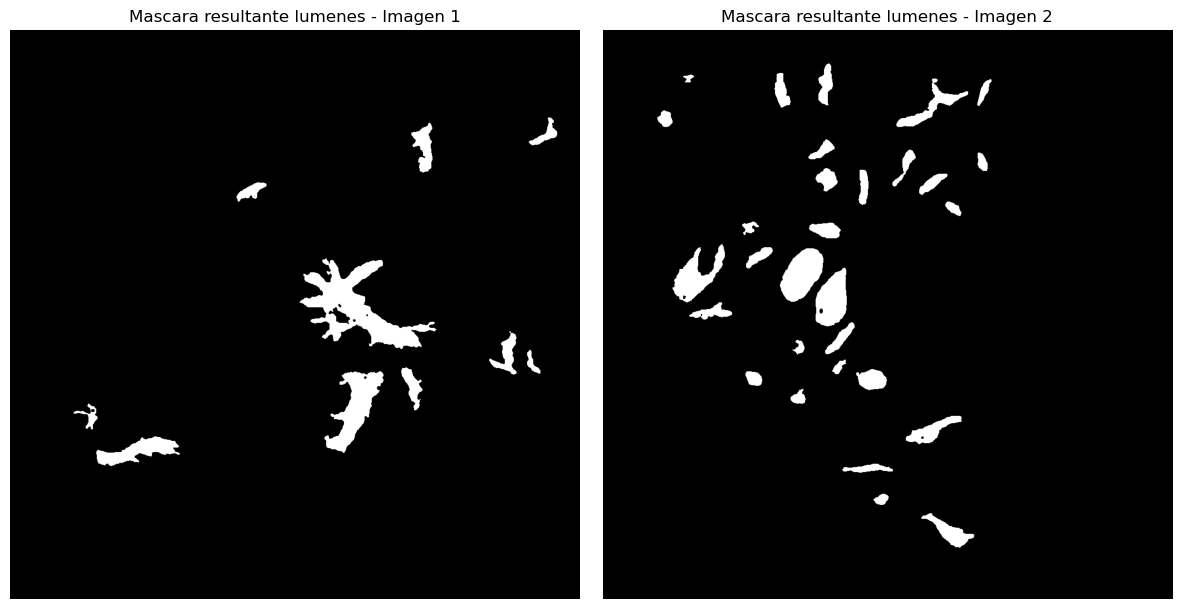

In [10]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.segmentation import clear_border, flood


# --- FUNCIÓN AUTOMÁTICA USANDO CLEAR_BORDER + REGION GROWING ---
def aislar_lumenes_con_clear_border(mascara_limpia):
    # Eliminar automáticamente todo lo que toca los bordes
    # Esto nos deja una máscara temporal que SOLO contiene los lúmenes internos
    solo_lumenes_internos = clear_border(mascara_limpia)

    # Encontrar las regiones de estos lúmenes internos para obtener sus centros (semillas)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        solo_lumenes_internos.astype("uint8")
    )

    # Lienzo negro vacío para reconstruir el resultado final con Region Growing
    mascara_lumenes = np.zeros_like(mascara_limpia, dtype=bool)

    # 3. Recorrer los lúmenes encontrados y usarlos como semillas para el algoritmo 'flood'
    for i in range(1, num_labels):
        cx, cy = centroids[i]
        semilla = (int(cy), int(cx))  # Coordenada en formato (fila, columna)

        # Aplicar la expansión por región (Region Growing) requerida por el examen
        expansion = flood(mascara_limpia, semilla)

        # Unir las regiones expandidas usando el operador lógico OR
        mascara_lumenes = mascara_lumenes | expansion

    return mascara_lumenes


# Ejecucion del algortimo
lumenes_img1 = aislar_lumenes_con_clear_border(mascara1_limpia)
lumenes_img2 = aislar_lumenes_con_clear_border(mascara2_limpia)

# Vizualisacion de los datos
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Mostrar Imagen 1
axes[0].imshow(lumenes_img1, cmap="gray")
axes[0].set_title("Mascara resultante lumenes - Imagen 1")
axes[0].axis("off")

# Mostrar Imagen 2
axes[1].imshow(lumenes_img2, cmap="gray")
axes[1].set_title("Mascara resultante lumenes - Imagen 2")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#### 5) Rellenar los objetos de los lúmenes

In [ ]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology
# Visualizar la máscara resultante

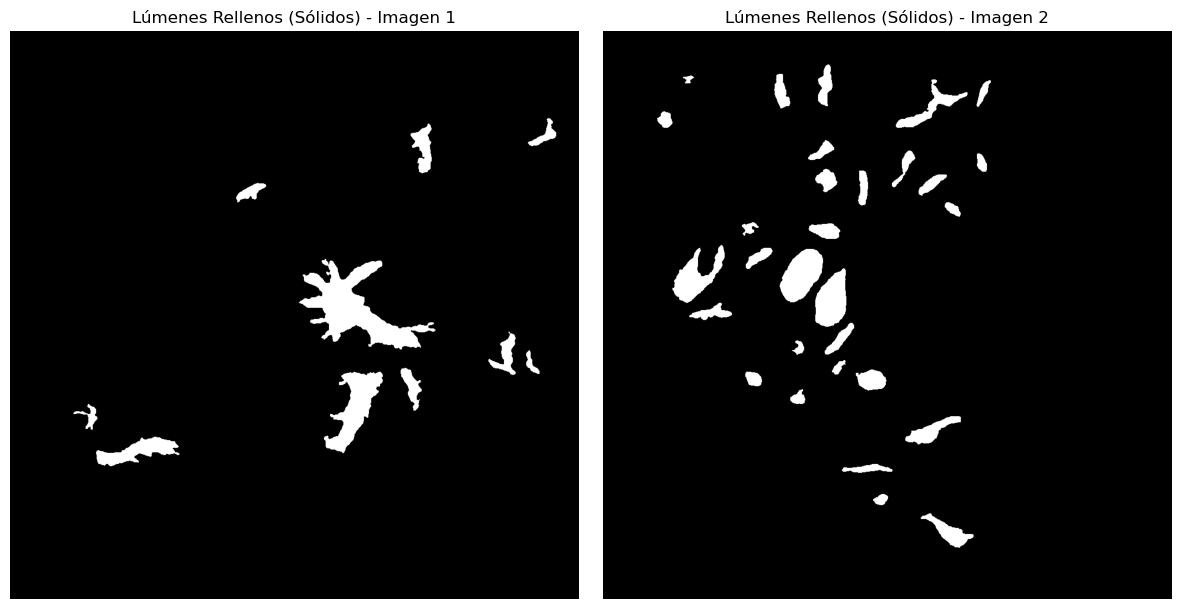

In [44]:
#Importamos las librerias necesarias
import matplotlib.pyplot as plt
from scipy.ndimage import binary_fill_holes

# APLICAR BINARY_FILL_HOLES
# Rellenar los lúmenes usando las máscaras obtenidas en el paso 4
lumenes_rellenos_img1 = binary_fill_holes(lumenes_img1)
lumenes_rellenos_img2 = binary_fill_holes(lumenes_img2)

# Visualizamos la mascara resultante
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Mostrar Imagen 1 con lúmenes rellenos
axes[0].imshow(lumenes_rellenos_img1, cmap="gray")
axes[0].set_title("Lúmenes Rellenos (Sólidos) - Imagen 1")
axes[0].axis("off")

# Mostrar Imagen 2 con lúmenes rellenos
axes[1].imshow(lumenes_rellenos_img2, cmap="gray")
axes[1].set_title("Lúmenes Rellenos (Sólidos) - Imagen 2")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

In [ ]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios
# para que los contornos en verde sean perfectamente visibles. 
# Visualizar la imagen superpuesta

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


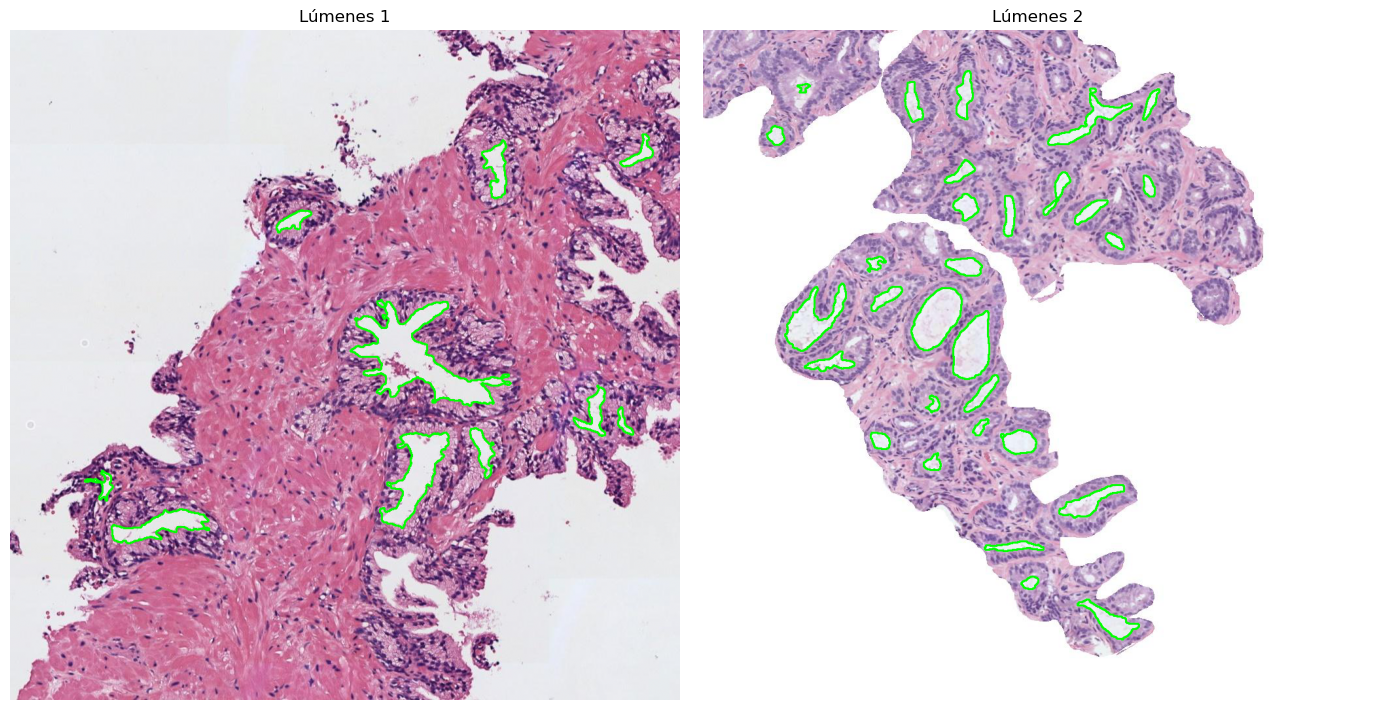

In [46]:
#Importamos las librerias
import cv2
import matplotlib.pyplot as plt

# Pasar a RGB para poder pintar a color
img1_rgb = (
    img1.copy() if len(img1.shape) == 3 else cv2.cvtColor(img1, cv2.COLOR_GRAY2RGB)
)
img2_rgb = (
    img2.copy() if len(img2.shape) == 3 else cv2.cvtColor(img2, cv2.COLOR_GRAY2RGB)
)

# IMAGEN 1
# Sacar contornos de afuera
contornos1, _ = cv2.findContours(
    lumenes_rellenos_img1.astype("uint8"),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE,
)
# Pintar de verde con grosor 2
cv2.drawContours(img1_rgb, contornos1, -1, (0, 255, 0), 2)

# IMAGEN 2 
# Sacar contornos de afuera
contornos2, _ = cv2.findContours(
    lumenes_rellenos_img2.astype("uint8"),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE,
)
# Pintar de verde
cv2.drawContours(img2_rgb, contornos2, -1, (0, 255, 0), 2)

# RESULTADOS
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(img1_rgb)
axes[0].set_title("Lúmenes 1")
axes[0].axis("off")

axes[1].imshow(img2_rgb)
axes[1].set_title("Lúmenes 2")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#### 7) Identificar y cropear el lumen más grande

In [ ]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.
# Visualizar el lumen cropeado.

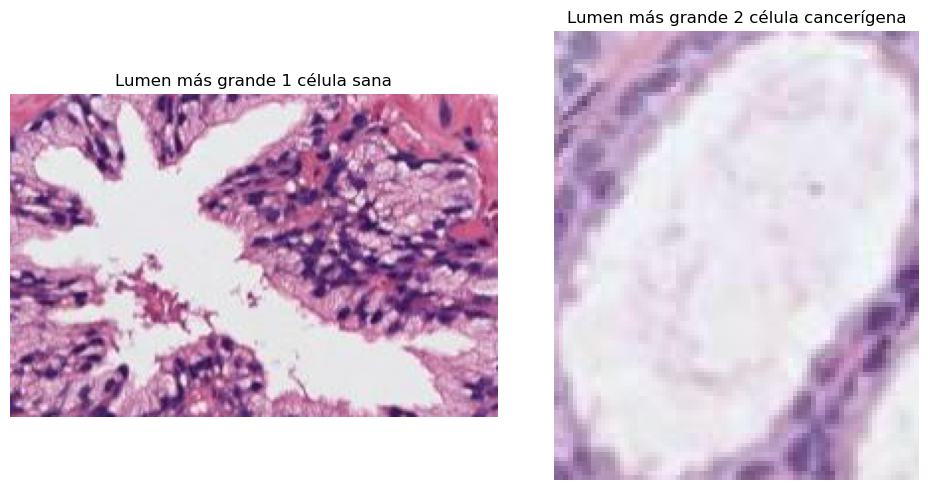

In [50]:
import cv2
import matplotlib.pyplot as plt

# Crear copias limpias de las imágenes originales (sin pintarles nada encima)
img1_limpia = (
    img1.copy() if len(img1.shape) == 3 else cv2.cvtColor(img1, cv2.COLOR_GRAY2RGB)
)
img2_limpia = (
    img2.copy() if len(img2.shape) == 3 else cv2.cvtColor(img2, cv2.COLOR_GRAY2RGB)
)

# IMAGEN 1
# Encontrar contornos en la máscara rellena
contornos1, _ = cv2.findContours(
    lumenes_rellenos_img1.astype("uint8"),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE,
)
# Buscar el contorno más grande
lumen_grande1 = max(contornos1, key=cv2.contourArea)
# Coordenadas de la caja para recortar
x1, y1, w1, h1 = cv2.boundingRect(lumen_grande1)
# Recortar de la imagen limpia
crop1 = img1_limpia[y1 : y1 + h1, x1 : x1 + w1]

# IMAGEN 2
# Encontrar contornos
contornos2, _ = cv2.findContours(
    lumenes_rellenos_img2.astype("uint8"),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE,
)
# Buscar el más grande
lumen_grande2 = max(contornos2, key=cv2.contourArea)
# Coordenadas de la caja
x2, y2, w2, h2 = cv2.boundingRect(lumen_grande2)
# Recortar de la imagen limpia
crop2 = img2_limpia[y2 : y2 + h2, x2 : x2 + w2]

# MOSTRAMOS LOS RESULTADOS 
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(crop1)
axes[0].set_title("Lumen más grande 1 célula sana")
axes[0].axis("off")

axes[1].imshow(crop2)
axes[1].set_title("Lumen más grande 2 célula cancerígena")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado 

In [ ]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.
# 1) Área
# 2) Área de la bounding box
# 3) Área convexa
# 4) Exentricidad
# 5) Diámetro equivalente
# 6) Extensión
# 7) Diámetro Feret
# 8) Longitud del eje mayor
# 9) Longitud del eje menor
# 10) Orientación
# 11) Perímetro
# 12) Solidez
# 13) Compacidad

In [57]:
import cv2
import numpy as np
import pandas as pd

# calculamos las 13 propiedades
def calcular_caracteristicas(contorno):
    area = cv2.contourArea(contorno)
    x, y, w, h = cv2.boundingRect(contorno)
    area_bbox = w * h
    area_convex = cv2.contourArea(cv2.convexHull(contorno))
    
    if len(contorno) >= 5:
        _, (MA, ma), angle = cv2.fitEllipse(contorno)
    else:
        MA, ma, angle = 0, 0, 0
        
    eccentricity = np.sqrt(1 - (ma**2 / MA**2)) if (MA > 0 and MA >= ma) else 0
    eq_diameter = np.sqrt(4 * area / np.pi)
    extent = area / area_bbox if area_bbox > 0 else 0
    feret_diam = max(cv2.minAreaRect(contorno)[1])
    perimeter = cv2.arcLength(contorno, True)
    solidity = area / area_convex if area_convex > 0 else 0
    compactness = (4 * np.pi * area) / (perimeter**2) if perimeter > 0 else 0

    return [area, area_bbox, area_convex, eccentricity, eq_diameter, extent, 
            feret_diam, max(MA, ma), min(MA, ma), angle, perimeter, solidity, compactness]

# Nombres limpios
nombres = [
    "Área", "Área de la bounding box", "Área convexa", "Exentricidad",
    "Diámetro equivalente", "Extensión", "Diámetro Feret", 
    "Longitud del eje mayor", "Longitud del eje menor", "Orientación",
    "Perímetro", "Solidez", "Compacidad"
]

# Cálculo de resultados redondeados
features1 = [round(x, 4) for x in calcular_caracteristicas(lumen_grande1)]
features2 = [round(x, 4) for x in calcular_caracteristicas(lumen_grande2)]

# Crear y mostrar la tabla limpia
df = pd.DataFrame({
    "Característica": nombres,
    "Lumen 1 (Sana)": features1,
    "Lumen 2 (Cáncer)": features2
})

# Visualización profesional sin índices
display(df.style.hide(axis="index"))

Característica,Lumen 1 (Sana),Lumen 2 (Cáncer)
Área,13542.000000,4762.500000
Área de la bounding box,40098.000000,7488.000000
Área convexa,28984.000000,4881.000000
Exentricidad,0.000000,0.000000
Diámetro equivalente,131.309600,77.870400
Extensión,0.337700,0.636000
Diámetro Feret,248.475800,103.448700
Longitud del eje mayor,229.971200,106.164200
Longitud del eje menor,141.897900,57.497300
Orientación,103.874300,32.083800
